In [45]:
#Librerias a usar
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
#Lectura
ruta = "../data/processed/housing_cleaned_2026-01-03.csv"
data = pd.read_csv(ruta) 

In [47]:
# ver las variables categoricas y las numericas
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  int64  
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


None

In [48]:
#Caracteristicas generales
from IPython.display import display

print(data.shape)
display(data.head())

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129,322,126,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200.0,NEAR BAY


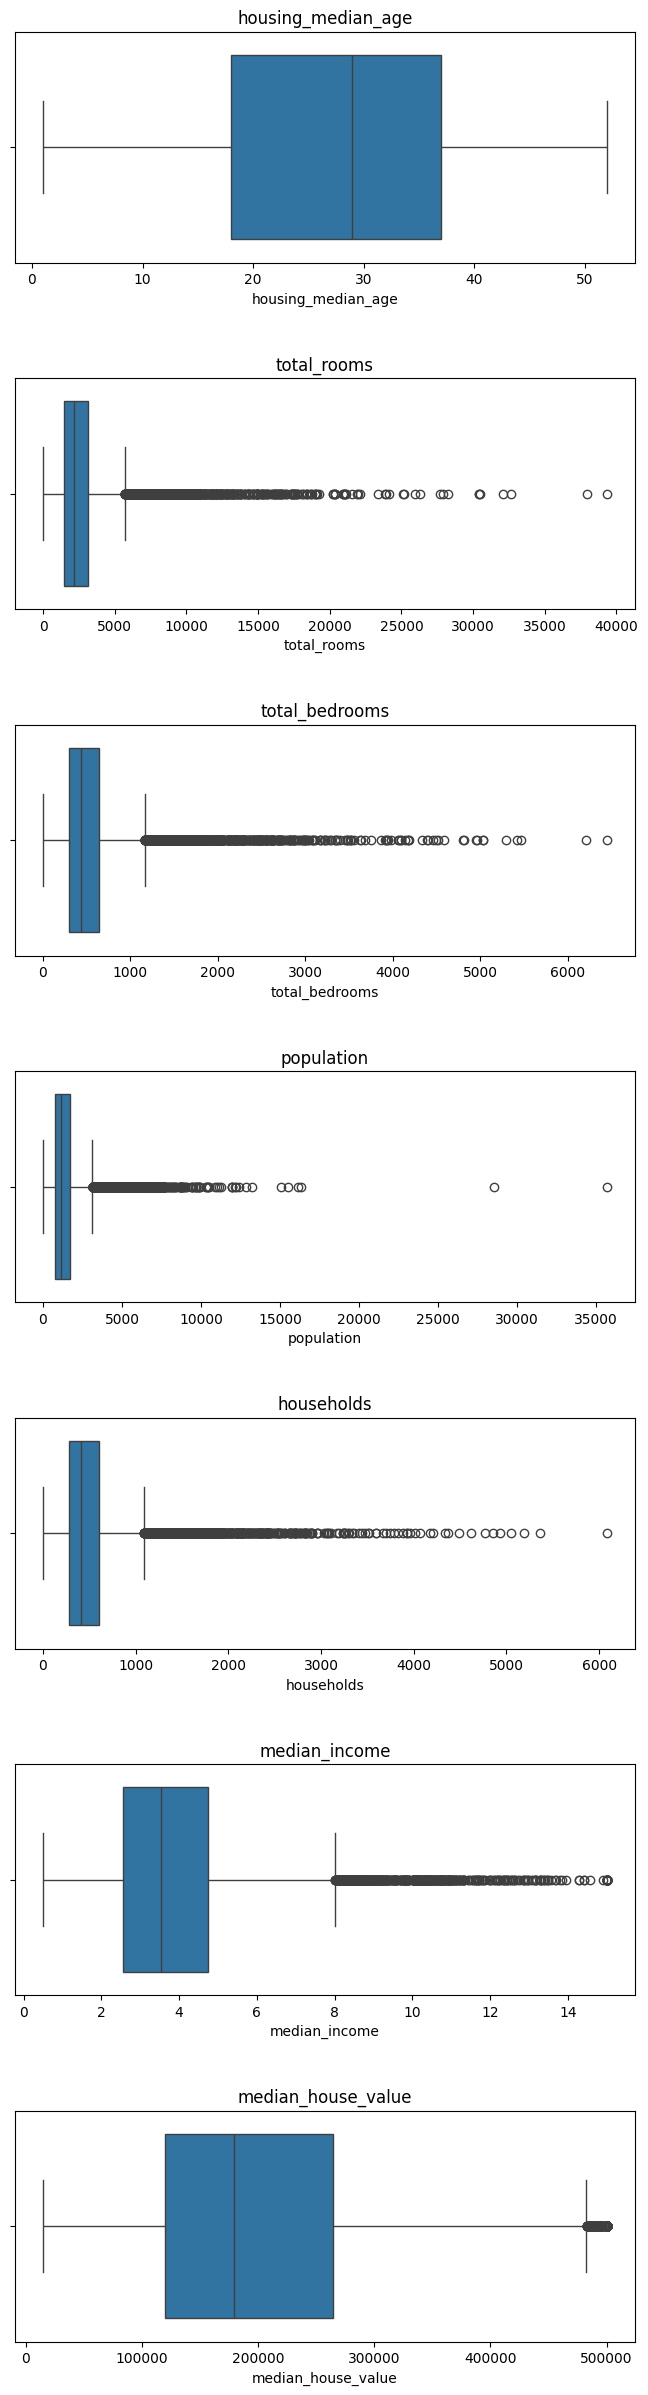

In [ ]:
cols_num = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

fig, ax = plt.subplots(nrows= 7, ncols=1, figsize = (8,30))
fig.subplots_adjust(hspace= 0.5)

for i, col in enumerate(cols_num):
    
    sns.boxplot(x = col, data= data, ax=ax[i])
    ax[i].set_title(col)

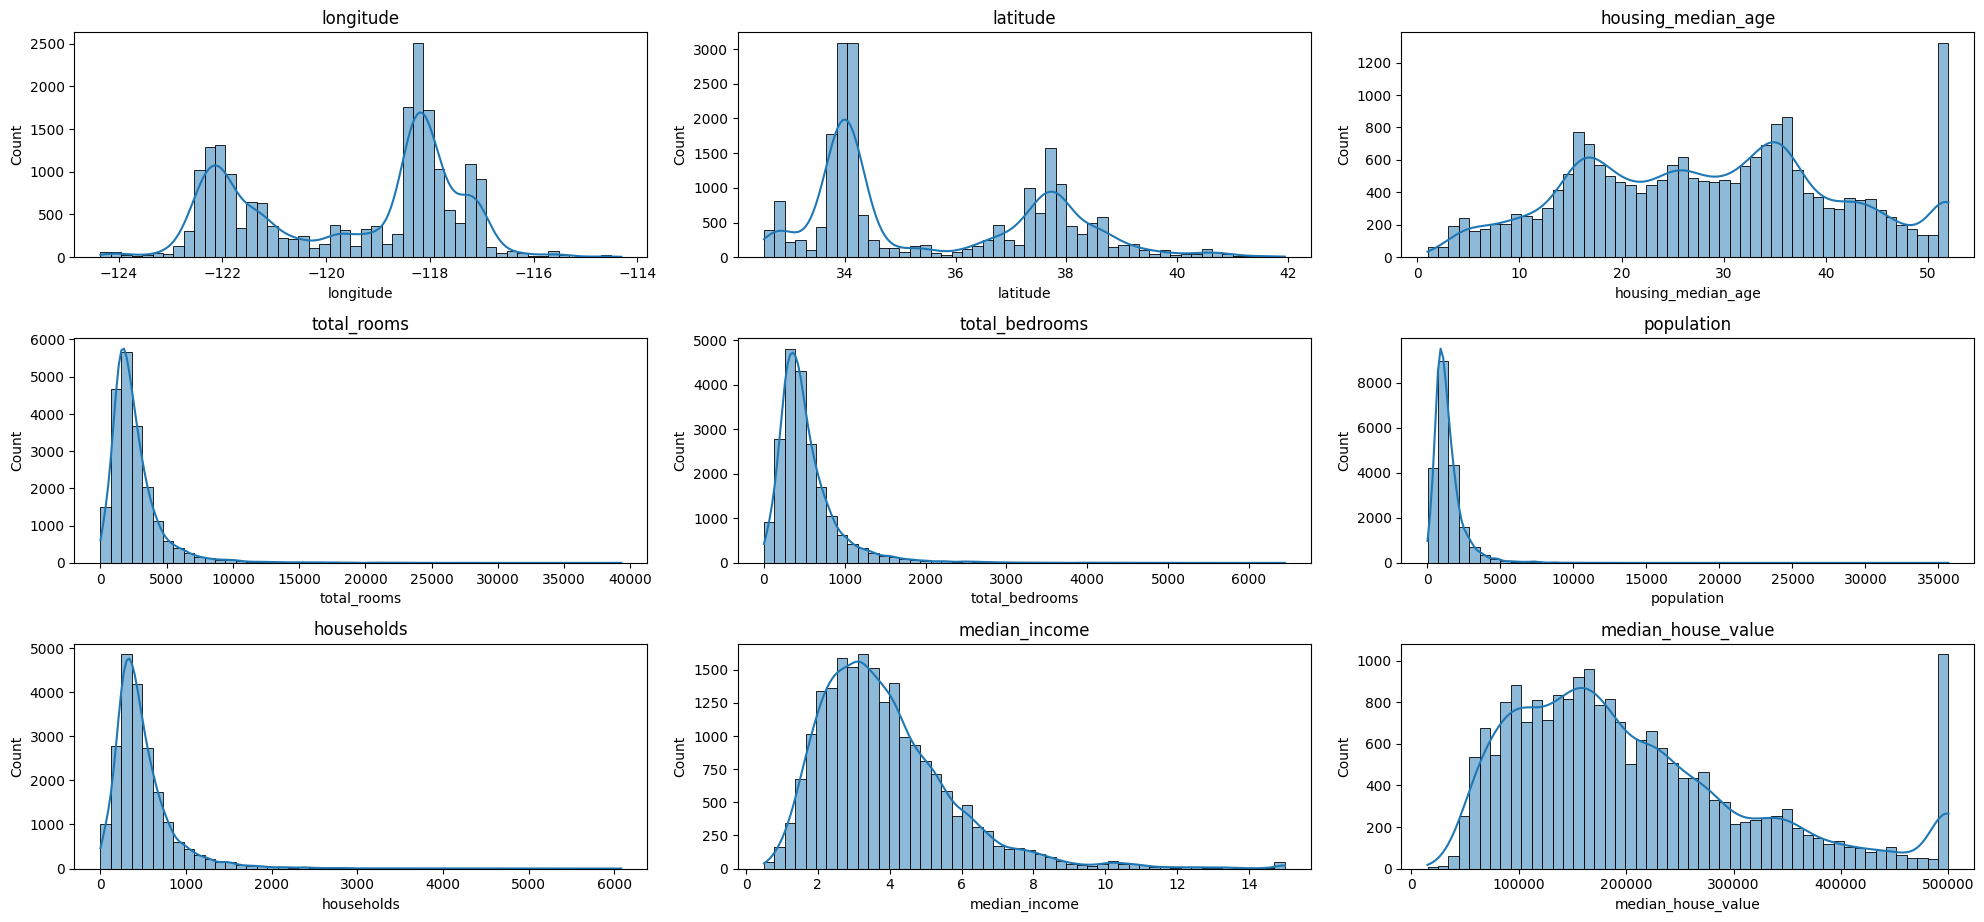

In [50]:
num_cols = data.select_dtypes(include='number').columns

plt.figure(figsize=(20, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 3, i)  # ajustá filas/columnas según cantidad
    sns.histplot(
        data[col],
        edgecolor='black',
        bins=50,
        kde=True
    )
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

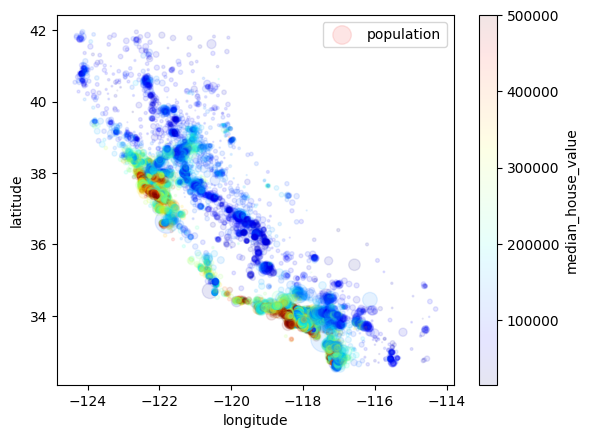

In [51]:
data.plot(kind='scatter', x='longitude',y= 'latitude', alpha = 0.1, s=data['population']/100, label = 'population', c = "median_house_value", cmap = plt.get_cmap('jet'))

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


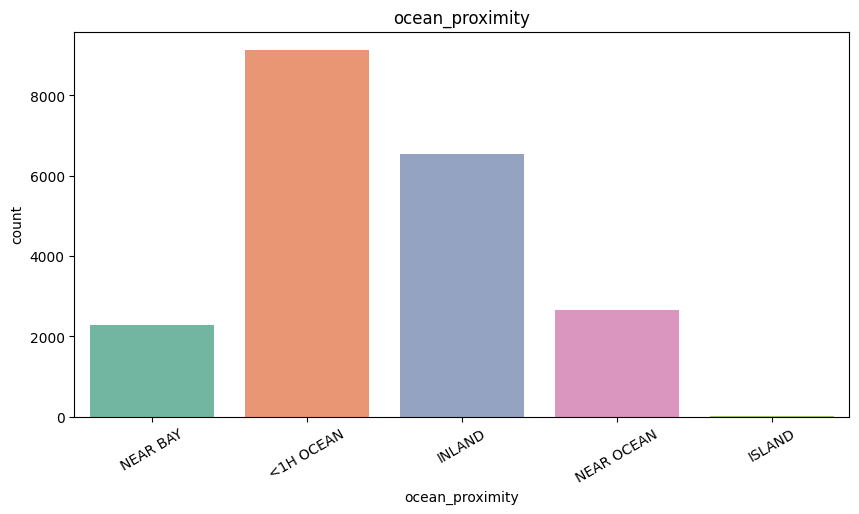

In [52]:
print(data['ocean_proximity'].value_counts())
cols_cat = ['ocean_proximity']
fig, ax = plt.subplots(nrows= 1, ncols=1, figsize = (10,5))
fig.subplots_adjust(hspace=1)
ax = [ax]

for i, col, in enumerate(cols_cat):
    sns.countplot(x=col, data=data,hue=col, palette="Set2",legend=False, ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis='x', rotation=30)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000


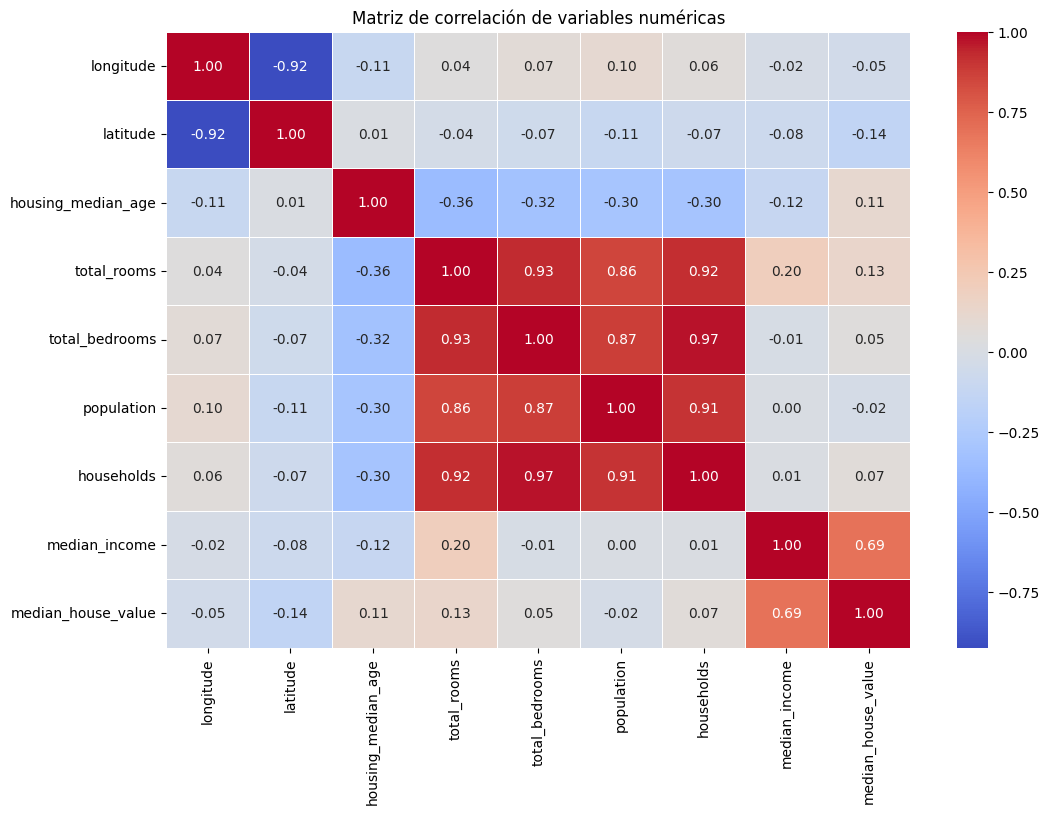

In [58]:
display(data.select_dtypes(include='number').corr())
corr_matrix = data.select_dtypes(include='number').corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación de variables numéricas")
plt.show()

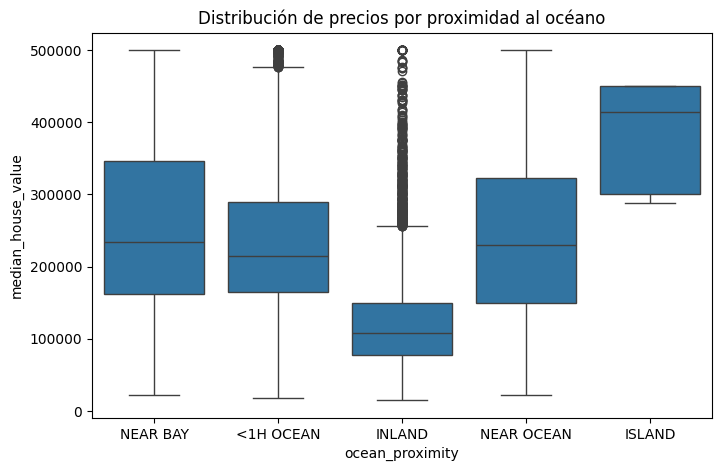

In [54]:
# Boxplot por proximidad al océano
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x="ocean_proximity", y="median_house_value")
plt.title("Distribución de precios por proximidad al océano")
plt.show()

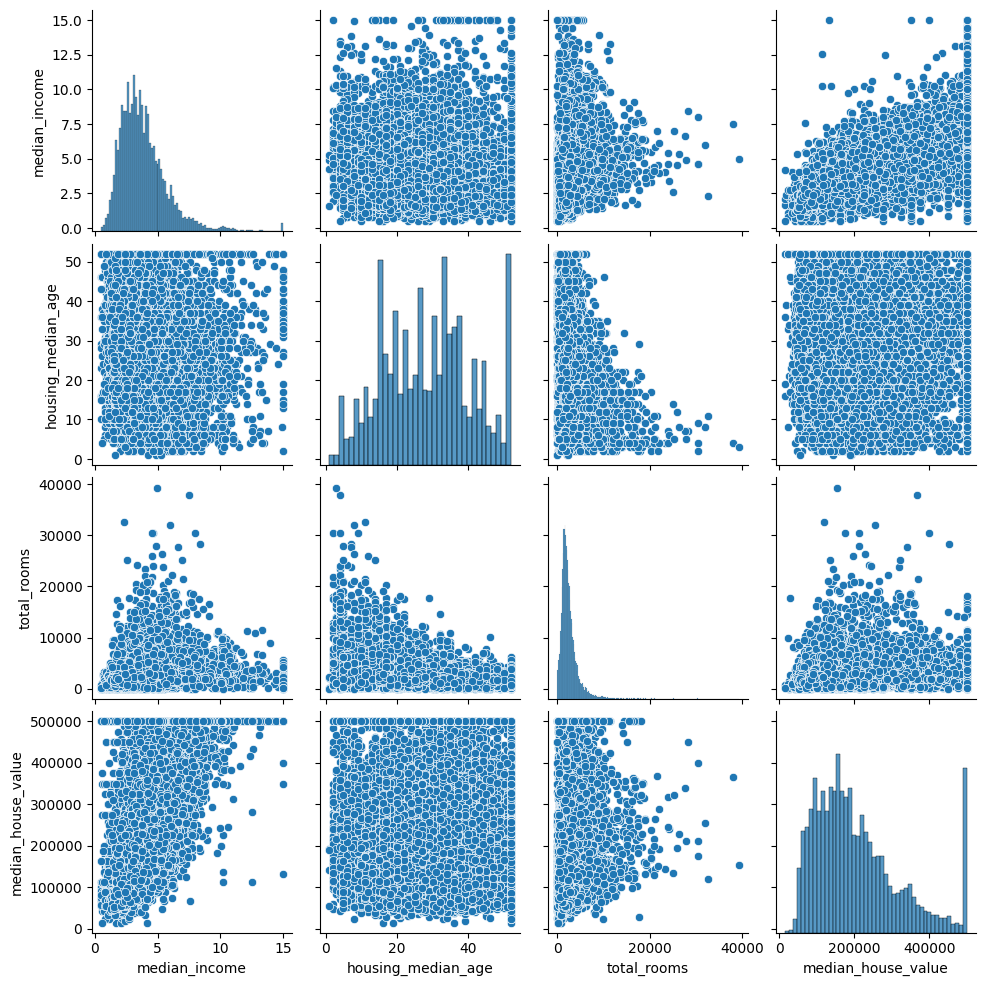

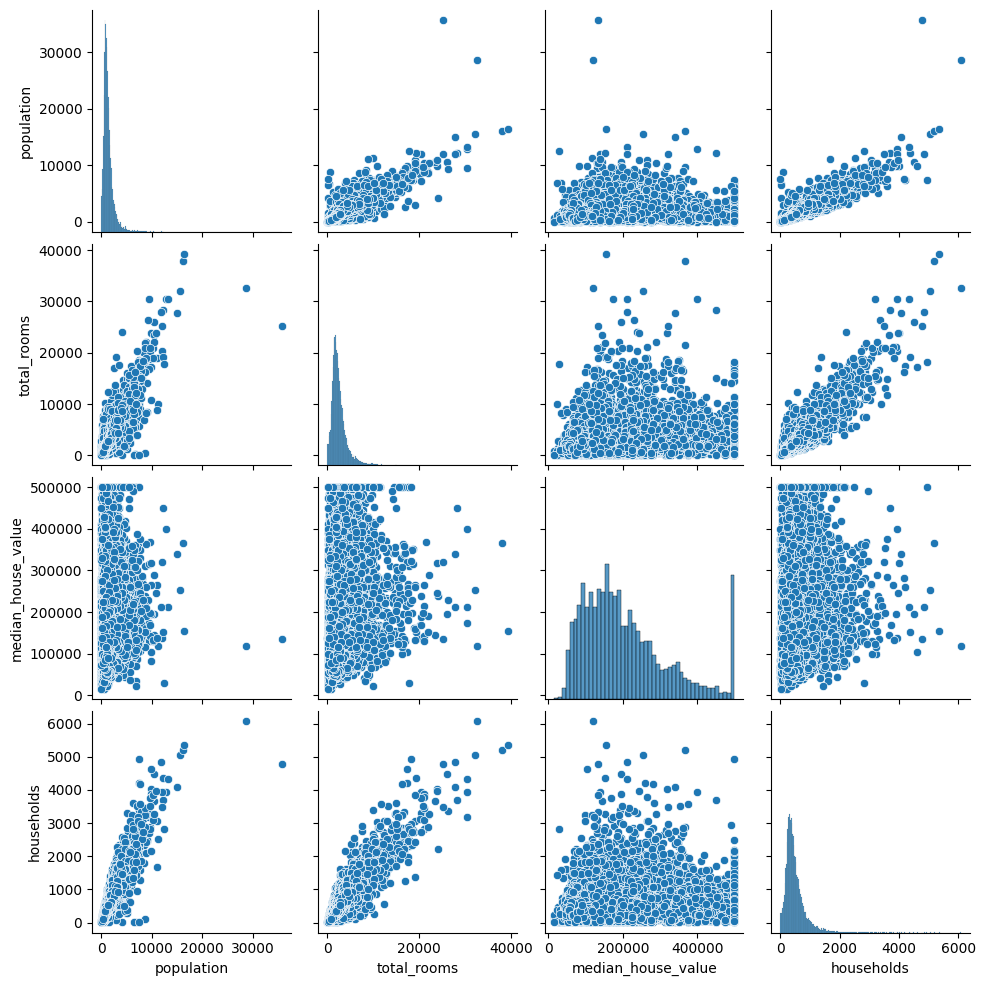

In [69]:
sns.pairplot(data[["median_income", "housing_median_age", "total_rooms", "median_house_value"]])
plt.show()
sns.pairplot(data[["population", "total_rooms", "median_house_value", "households"]])
plt.show()


El pairplot confirma que median_income es la variable con mayor relación con el valor medio de la vivienda. Otras variables, como total_rooms y housing_median_age, muestran relaciones más débiles de forma individual, lo que sugiere la necesidad de crear variables derivadas para capturar mejor la información estructural del dataset. Asimismo, se observan efectos de censura en variables clave que deben ser considerados durante el modelado.

Las variables de conteo presentan fuertes relaciones entre sí, lo que indica redundancia y posible multicolinealidad. Sin embargo, su relación directa con el valor de la vivienda es débil cuando se consideran de forma individual. Esto sugiere que el poder predictivo de estas variables se incrementa al normalizarlas mediante ratios, capturando mejor la estructura del dataset.

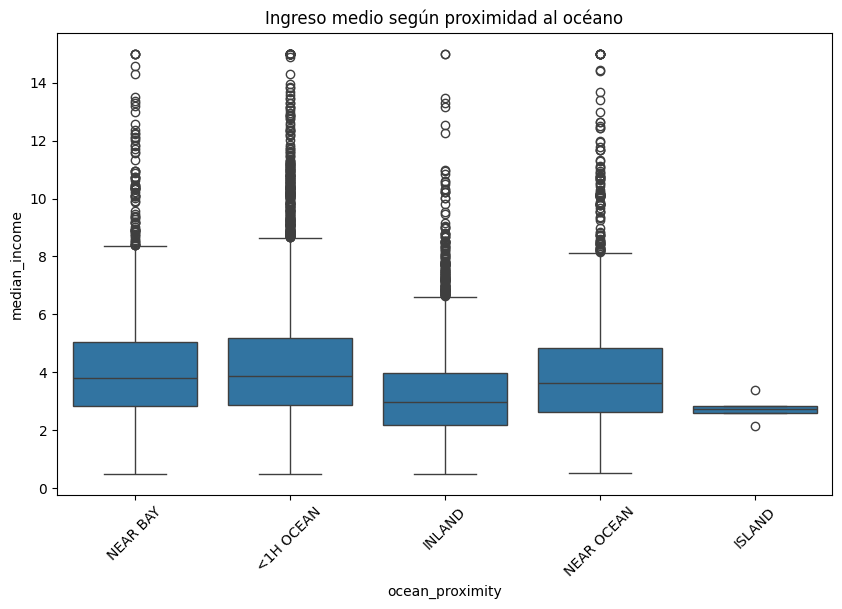

In [73]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='ocean_proximity',
    y='median_income',
    data=data
)
plt.xticks(rotation=45)
plt.title("Ingreso medio según proximidad al océano")
plt.show()


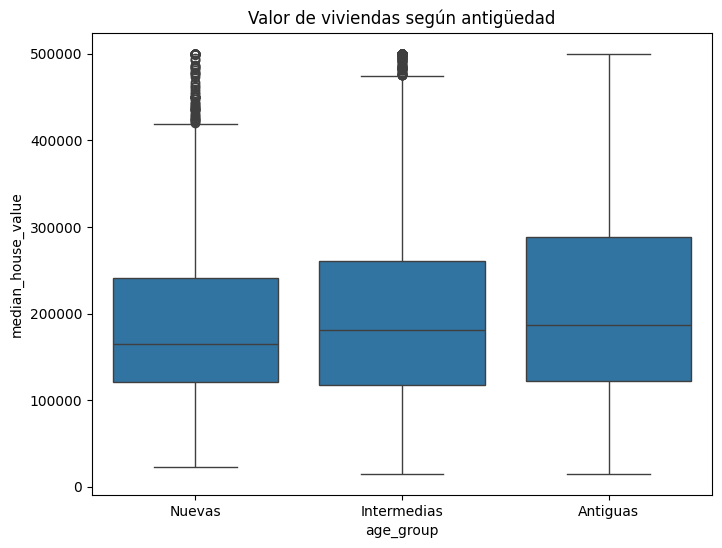

In [74]:
data['age_group'] = pd.cut(
    data['housing_median_age'],
    bins=[0, 15, 35, 60],
    labels=['Nuevas', 'Intermedias', 'Antiguas']
)
plt.figure(figsize=(8,6))
sns.boxplot(
    x='age_group',
    y='median_house_value',
    data=data
)
plt.title("Valor de viviendas según antigüedad")
plt.show()


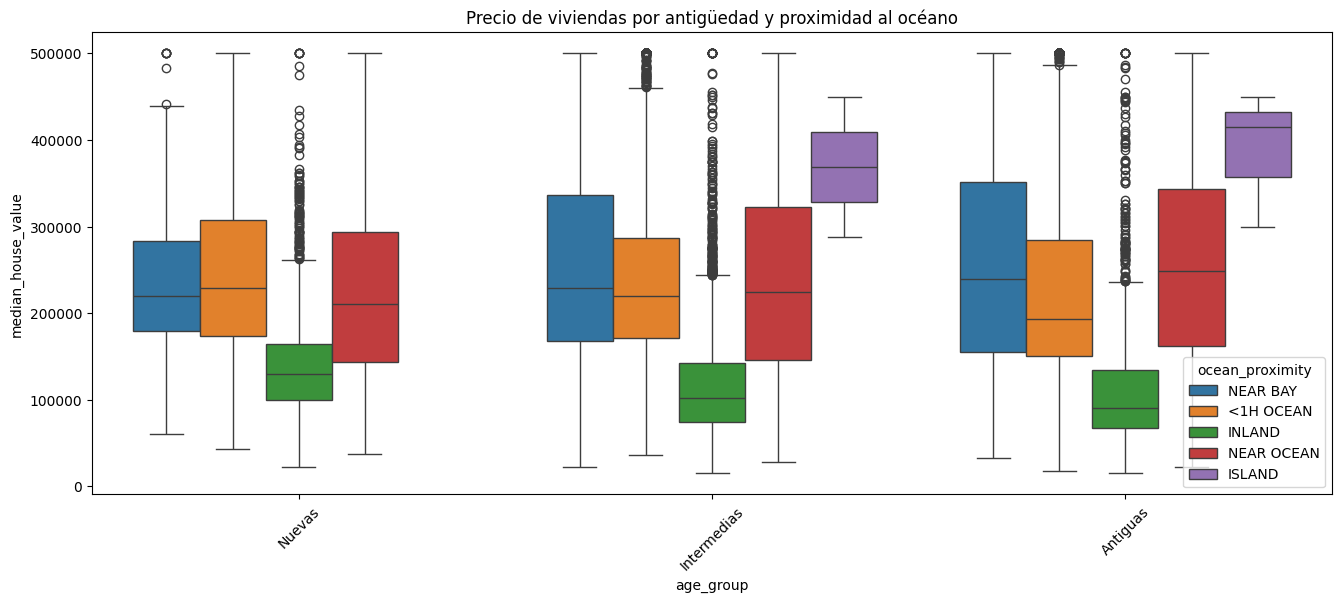

In [76]:
plt.figure(figsize=(16,6))
sns.boxplot(
    x='age_group',
    y='median_house_value',
    hue='ocean_proximity',
    data=data
)
plt.xticks(rotation=45)
plt.title("Precio de viviendas por antigüedad y proximidad al océano")
plt.show()
